# Trace Count v8: pure needle-count extension of v2

目标：保持 v2 的 prompt 长度 256，只把 needle count 扩展到 1–30。

Main 只训练两个模型：一个 non-thinking，一个 thinking。训练和验证都覆盖 1–30，
因此 21–30 不再包含“未训练数字 token”的伪 OOD。trace index 与最终答案共享 `<1>...<30>`。

输出重点：

1. autoregressive final-count accuracy by gold count；
2. `tf_accuracy` / `ar_accuracy` 同时保存，图和阈值默认使用 `ar_accuracy`；
3. `val_1_10`、`val_11_20`、`val_21_30` 三个 balanced validation split；
4. first count below 0.9 accuracy；
5. CoT 和 non-thinking 的崩塌阈值是否不同。
            

## 1. Setup

## Google Drive Login

在实验开始时挂载一次 Google Drive。后面的保存 cell 会复用该挂载，因此长实验结束时不会再次弹出登录流程。

In [ ]:
from pathlib import Path
import sys

DRIVE_RESULTS_ROOT = Path(
    "/content/drive/MyDrive/Colab_Notebooks/CoT_Counting/"
    "Synthetic_CoT_NiaH_Count/colab_results"
)
DRIVE_MOUNTED = False

def ensure_google_drive_mounted() -> bool:
    global DRIVE_MOUNTED
    if not ("google.colab" in sys.modules or Path("/content").exists()):
        print("Not in Colab; Google Drive mount skipped.")
        return False
    from google.colab import drive
    if not Path("/content/drive/MyDrive").exists():
        drive.mount("/content/drive")
    DRIVE_RESULTS_ROOT.mkdir(parents=True, exist_ok=True)
    DRIVE_MOUNTED = True
    print("Google Drive ready:", DRIVE_RESULTS_ROOT)
    return True

ensure_google_drive_mounted()

In [1]:
from __future__ import annotations

from pathlib import Path
import os
import shutil
import subprocess
import sys

REPO_URL = "https://github.com/Twist-Shan/Synthetic_CoT_NiaH_Count.git"
IN_COLAB = "google.colab" in sys.modules or Path("/content").exists()
INSTALL_DEPS = False

if IN_COLAB:
    repo_dir = Path("/content/Synthetic_CoT_NiaH_Count")
    cwd = Path.cwd()
    if (cwd / ".git").exists() or (cwd / "README.md").exists():
        repo_dir = cwd
    elif not repo_dir.exists():
        subprocess.run(["git", "clone", REPO_URL, str(repo_dir)], check=True)
    os.chdir(repo_dir)

ROOT = Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

if INSTALL_DEPS:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "transformers>=4.40", "pandas", "matplotlib", "tqdm"], check=True)

subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-e", ".", "--no-deps"], check=True)

import pandas as pd
from IPython.display import Markdown, display, Image

display(Markdown(f"**Repo root:** `{ROOT}`"))

**Repo root:** `/content/Synthetic_CoT_NiaH_Count`

## 2. Runtime settings

In [2]:
PRESET = "main"  # "debug" or "main"
OUT_ROOT = "runs/trace_count_v8_many_needles"
DEVICE = "cuda" if __import__("torch").cuda.is_available() else "cpu"
SKIP_COMPLETED = True
print({"PRESET": PRESET, "OUT_ROOT": OUT_ROOT, "DEVICE": DEVICE})
            

{'PRESET': 'main', 'OUT_ROOT': 'runs/trace_count_v8_many_needles', 'DEVICE': 'cuda'}


## 3. Run v8 sweep

In [3]:
from synthetic_counting_extensions.v7_v8_sweeps import preset_configs, run_sweep

settings = preset_configs("v8", PRESET)
display(pd.DataFrame([vars(cfg) | {"effective_batch_size": cfg.effective_batch_size} for cfg in settings]))
display(Markdown(f"**Training runs:** `{len(settings)} setting × 2 models = {2 * len(settings)}`"))

combined = run_sweep("v8", PRESET, OUT_ROOT, skip_completed=SKIP_COMPLETED, device=DEVICE)
display(combined.head())
split_summary = (
    combined.groupby(["setting", "mode", "validation_split"], as_index=False)
    .agg(
        count_min=("count", "min"),
        count_max=("count", "max"),
        tf_accuracy=("tf_accuracy", "mean"),
        ar_accuracy=("ar_accuracy", "mean"),
        accuracy=("accuracy", "mean"),
        mae=("mae", "mean"),
    )
)
display(Markdown("## Validation performance by needle-count range"))
display(split_summary)
threshold = []
for (setting, mode), g in combined.groupby(["setting", "mode"]):
    bad = g[g["accuracy"] < 0.9]
    threshold.append({"setting": setting, "mode": mode, "first_count_below_0.9": int(bad["count"].iloc[0]) if len(bad) else "none"})
display(pd.DataFrame(threshold))
            

,experiment,preset,seed,seq_len,train_count_min,train_count_max,eval_count_min,eval_count_max,noise_vocab_size,marker_vocab_size,...,warmup_steps,weight_decay,log_every,eval_examples_per_count,ar_examples_per_count,n_layer,n_head,n_embd,device,effective_batch_size
0,v8,main,1234,256,1,30,1,30,64,10,...,500,0.1,50,200,50,4,4,256,cuda,128


**Training runs:** `1 setting × 2 models = 2`

v8 nonthinking:   0%|          | 0/10000 [00:00<?, ?it/s]

eval nonthinking:   0%|          | 0/6000 [00:00<?, ?it/s]

v8 thinking:   0%|          | 0/10000 [00:00<?, ?it/s]

eval thinking:   0%|          | 0/6000 [00:00<?, ?it/s]

,run_dir,setting,mode,count,n,n_ar,tf_accuracy,ar_accuracy,tf_mae,ar_mae,accuracy,mae,validation_split
0,runs/trace_count_v8_many_needles/v8_main_L256_...,v8_main_L256_train1-30_eval1-30_sharednum_seed...,nonthinking,1,200,50,1.0,1.0,0.0,0.0,1.0,0.0,val_1_10
1,runs/trace_count_v8_many_needles/v8_main_L256_...,v8_main_L256_train1-30_eval1-30_sharednum_seed...,nonthinking,2,200,50,1.0,1.0,0.0,0.0,1.0,0.0,val_1_10
2,runs/trace_count_v8_many_needles/v8_main_L256_...,v8_main_L256_train1-30_eval1-30_sharednum_seed...,nonthinking,3,200,50,1.0,1.0,0.0,0.0,1.0,0.0,val_1_10
3,runs/trace_count_v8_many_needles/v8_main_L256_...,v8_main_L256_train1-30_eval1-30_sharednum_seed...,nonthinking,4,200,50,1.0,1.0,0.0,0.0,1.0,0.0,val_1_10
4,runs/trace_count_v8_many_needles/v8_main_L256_...,v8_main_L256_train1-30_eval1-30_sharednum_seed...,nonthinking,5,200,50,1.0,1.0,0.0,0.0,1.0,0.0,val_1_10


## Validation performance by needle-count range

,setting,mode,validation_split,count_min,count_max,tf_accuracy,ar_accuracy,accuracy,mae
0,v8_main_L256_train1-30_eval1-30_sharednum_seed...,nonthinking,val_11_20,11,20,1.0,1.0,1.0,0.0
1,v8_main_L256_train1-30_eval1-30_sharednum_seed...,nonthinking,val_1_10,1,10,1.0,1.0,1.0,0.0
2,v8_main_L256_train1-30_eval1-30_sharednum_seed...,nonthinking,val_21_30,21,30,1.0,1.0,1.0,0.0
3,v8_main_L256_train1-30_eval1-30_sharednum_seed...,thinking,val_11_20,11,20,1.0,1.0,1.0,0.0
4,v8_main_L256_train1-30_eval1-30_sharednum_seed...,thinking,val_1_10,1,10,1.0,1.0,1.0,0.0
5,v8_main_L256_train1-30_eval1-30_sharednum_seed...,thinking,val_21_30,21,30,1.0,1.0,1.0,0.0


,setting,mode,first_count_below_0.9
0,v8_main_L256_train1-30_eval1-30_sharednum_seed...,nonthinking,none
1,v8_main_L256_train1-30_eval1-30_sharednum_seed...,thinking,none


## 4. Display reports

## v8_main_L256_train1-30_eval1-30_sharednum_seed1234
Report: `runs/trace_count_v8_many_needles/v8_main_L256_train1-30_eval1-30_sharednum_seed1234/report/report.html`

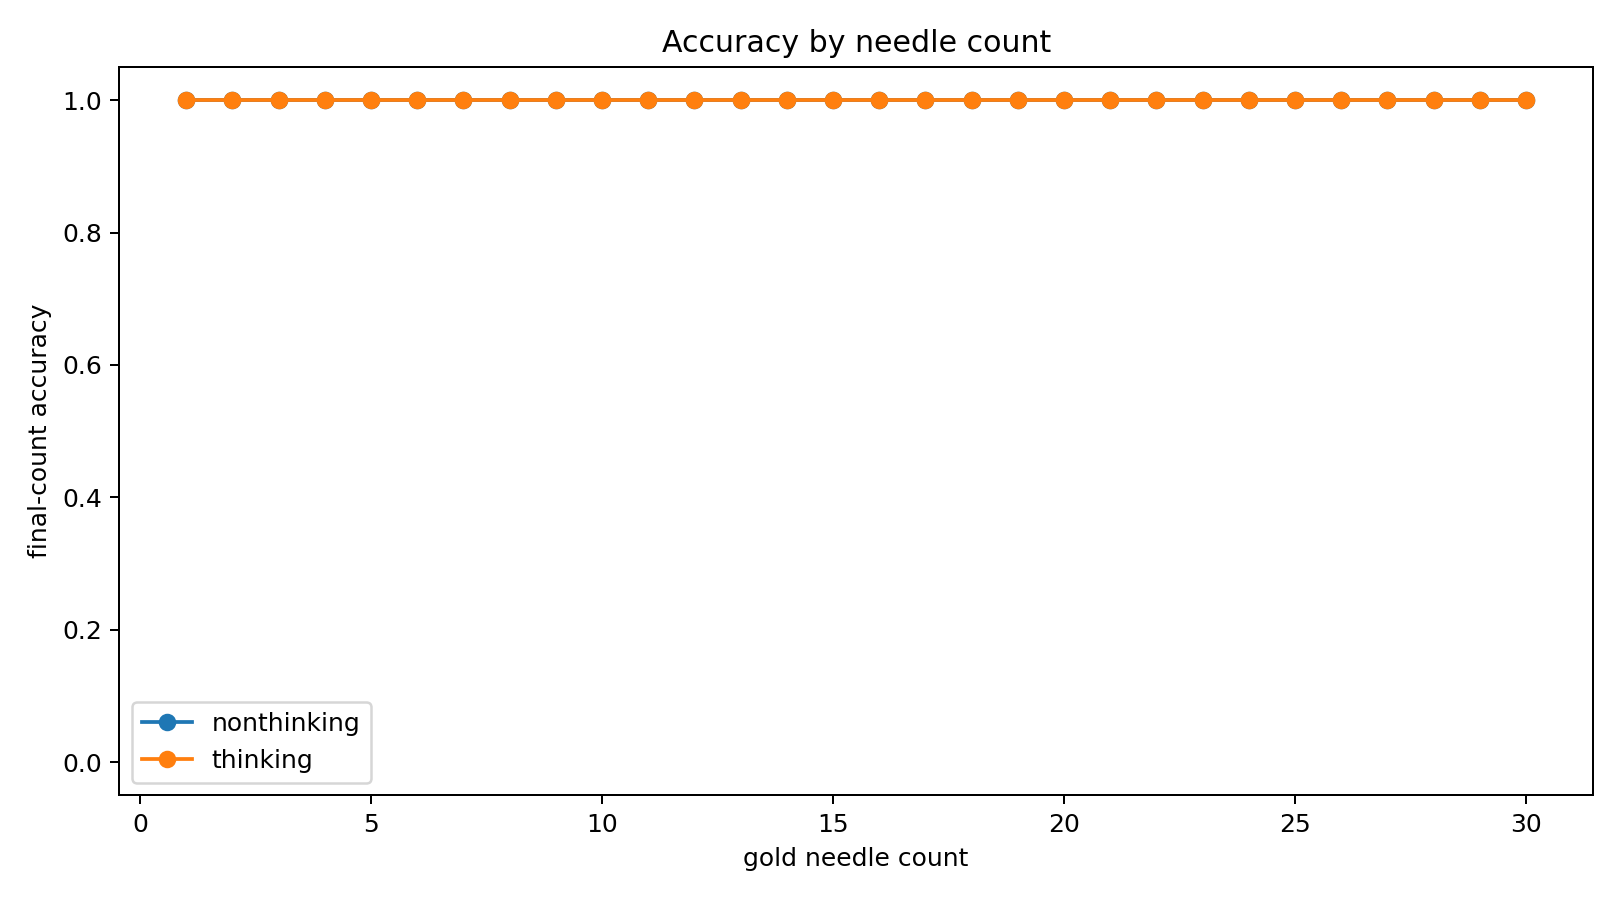

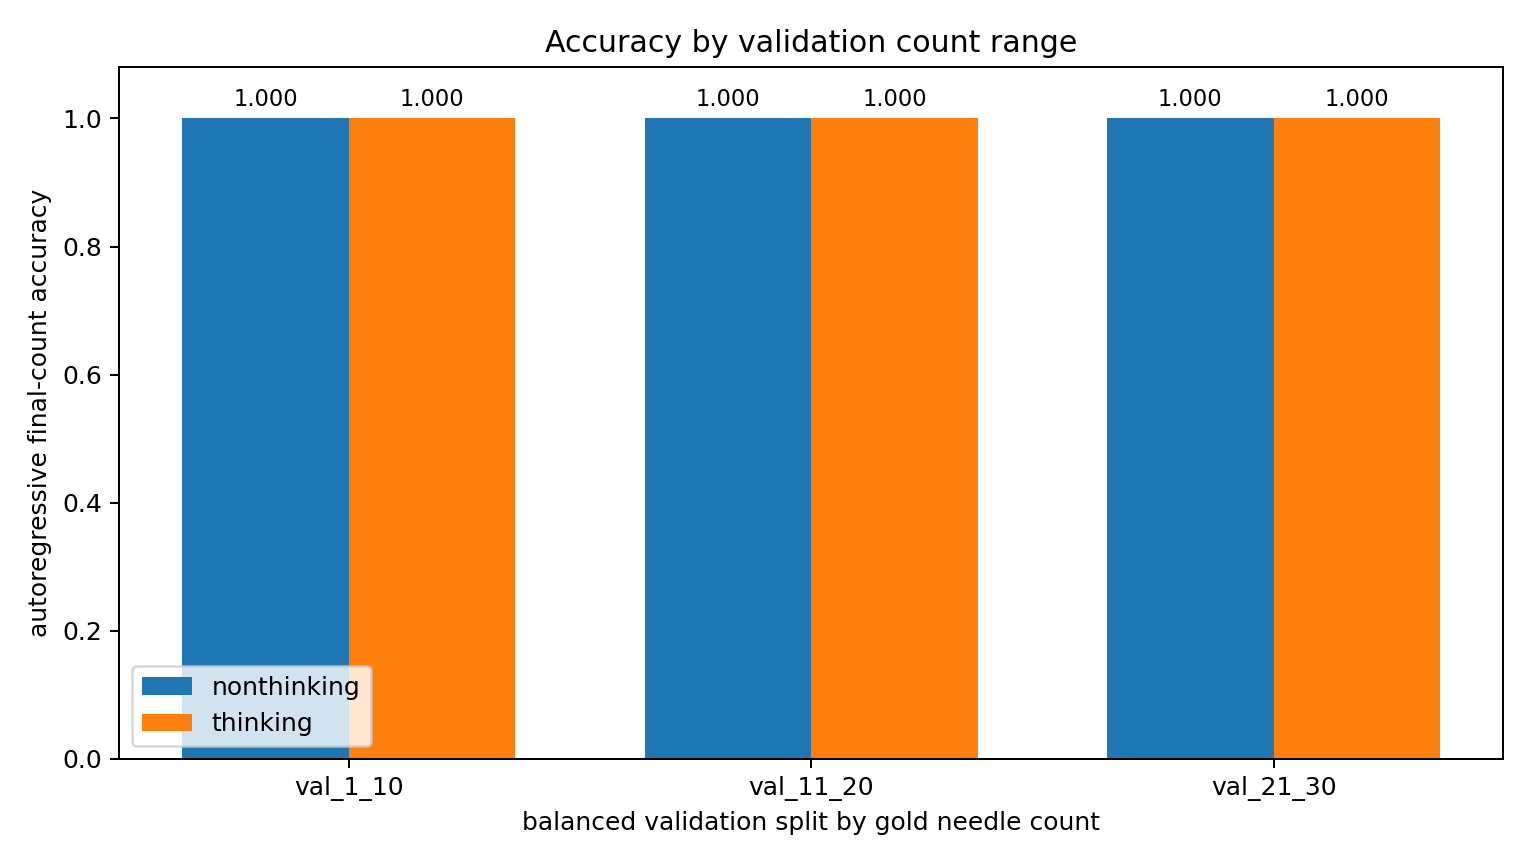

In [4]:
for run in Path(OUT_ROOT).glob("v8_*"):
    report = run / "report" / "report.html"
    figures = [
        run / "figures" / "accuracy_by_count.png",
        run / "figures" / "accuracy_by_validation_split.png",
    ]
    if figures[0].exists():
        display(Markdown(f"## {run.name}\nReport: `{report}`"))
        for fig in figures:
            if fig.exists():
                display(Image(filename=str(fig)))
            

## 5. Save / GitHub / disconnect

In [5]:
# Save result folder to Google Drive.
SAVE_TO_DRIVE = True
DRIVE_DEST_ROOT = "/content/drive/MyDrive/Colab_Notebooks/CoT_Counting/Synthetic_CoT_NiaH_Count/colab_results"

if SAVE_TO_DRIVE and IN_COLAB:
    from google.colab import drive
    ensure_google_drive_mounted()
    dest_root = Path(DRIVE_DEST_ROOT)
    dest_root.mkdir(parents=True, exist_ok=True)
    if "RUN_DIR" in globals() and RUN_DIR is not None:
        src = Path(RUN_DIR)
    elif "OUT_ROOT" in globals():
        src = Path(OUT_ROOT)
    else:
        src = None
    if src is not None and src.exists():
        dest = dest_root / src.name
        if dest.exists():
            shutil.rmtree(dest)
        shutil.copytree(src, dest)
        display(Markdown(f"**Saved to Drive:** `{dest}`"))
    else:
        display(Markdown("No RUN_DIR/OUT_ROOT found to save."))
else:
    display(Markdown("Drive save skipped."))

MessageError: Failed to issue request POST https://colab.research.google.com/tun/m/credentials-propagation/gpu-a100-s-kkb-ass1c2-esy4469qdwuk?authtype=dfs_ephemeral&version=2&dryrun=false&propagate=true&record=false&authuser=0: Bad Request
Response body: 
<!DOCTYPE html>
<html lang=en>
  <meta charset=utf-8>
  <meta name=viewport content="initial-scale=1, minimum-scale=1, width=device-width">
  <title>Error 400 (Bad Request)!!1</title>
  <style>
    *{margin:0;padding:0}html,code{font:15px/22px arial,sans-serif}html{background:#fff;color:#222;padding:15px}body{margin:7% auto 0;max-width:390px;min-height:180px;padding:30px 0 15px}* > body{background:url(//www.google.com/images/errors/robot.png) 100% 5px no-repeat;padding-right:205px}p{margin:11px 0 22px;overflow:hidden}ins{color:#777;text-decoration:none}a img{border:0}@media screen and (max-width:772px){body{background:none;margin-top:0;max-width:none;padding-right:0}}#logo{background:url(//www.google.com/images/logos/errorpage/error_l

In [ ]:
# Optional: commit and push notebook/code changes to GitHub.
PUSH_TO_GITHUB = False
GIT_COMMIT_MESSAGE = "Add synthetic counting experiment notebook"

if PUSH_TO_GITHUB:
    subprocess.run(["git", "status", "--short"], check=False)
    subprocess.run(["git", "add", "notebooks", "src/synthetic_counting_extensions", "scripts"], check=True)
    subprocess.run(["git", "commit", "-m", GIT_COMMIT_MESSAGE], check=True)
    subprocess.run(["git", "push"], check=True)
else:
    display(Markdown("GitHub push skipped. Set `PUSH_TO_GITHUB = True` after checking the diff."))

In [ ]:
# Optional: disconnect Colab runtime after saving.
AUTO_DISCONNECT_AFTER_SAVE = False

if AUTO_DISCONNECT_AFTER_SAVE and IN_COLAB:
    from google.colab import runtime
    runtime.unassign()
else:
    display(Markdown("Auto-disconnect skipped."))